# Exploratory Data Analysis : Dataset 2
## Defactify Image Dataset (HuggingFace)

---

## Purpose of this notebook

Before training any model, we must understand our data deeply. This EDA notebook answers:
- What does the Defactify dataset look like?
- How are images distributed across splits and classes?
- Is the dataset balanced? If not how imbalanced?
- What do real vs AI-generated scenes look like visually?
- What are the pixel-level differences between REAL and FAKE?
- Which AI generators (SD, DALL-E, Midjourney) produce the most convincing fakes?

## Dataset Summary

| Property | Value |
|---|---|
| **Source** | HuggingFace  Rajarshi-Roy-research/Defactify_Image_Dataset |
| **Total images** | 96,000 |
| **Format** | HuggingFace Parquet (Image + Caption + Label_A + Label_B) |
| **Real source** | MS COCO  everyday scenes (streets, animals, kitchens, objects) |
| **Fake source** | SD 2.1, SDXL, Stable Diffusion 3, DALL-E 3, Midjourney v6 |
| **Balance** | IMBALANCED (83% FAKE / 17% REAL) |

## 🎯 Target variables
- `Label_A` : **0 = REAL** / **1 = FAKE** (binary : what we use for training)
- `Label_B` : **0=Real, 1=SD21, 2=SDXL, 3=SD3, 4=DALL-E3, 5=Midjourney** (which generator)

---

## Step 1 : Imports & Load Dataset

In [ ]:
!pip install datasets --quiet
print('HuggingFace datasets installed')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from datasets import load_dataset
import random
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded ')

In [3]:
print('Loading Defactify dataset from HuggingFace...')
hf_data = load_dataset('Rajarshi-Roy-research/Defactify_Image_Dataset')
print('Dataset loaded ')
print()
print(hf_data)
print()
print('Available splits:', list(hf_data.keys()))
print('Available columns:', hf_data['train'].column_names)

data/test-00002-of-00008.parquet:   0%|          | 0.00/671M [00:00<?, ?B/s]

data/test-00003-of-00008.parquet:   0%|          | 0.00/477M [00:00<?, ?B/s]

data/test-00004-of-00008.parquet:   0%|          | 0.00/425M [00:00<?, ?B/s]

data/test-00005-of-00008.parquet:   0%|          | 0.00/425M [00:00<?, ?B/s]

data/test-00006-of-00008.parquet:   0%|          | 0.00/443M [00:00<?, ?B/s]

data/test-00007-of-00008.parquet:   0%|          | 0.00/449M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/9000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/42000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/45000 [00:00<?, ? examples/s]

Dataset loaded ✅

DatasetDict({
    validation: Dataset({
        features: ['Caption', 'Image', 'Label_A', 'Label_B'],
        num_rows: 9000
    })
    train: Dataset({
        features: ['Caption', 'Image', 'Label_A', 'Label_B'],
        num_rows: 42000
    })
    test: Dataset({
        features: ['Caption', 'Image', 'Label_A', 'Label_B'],
        num_rows: 45000
    })
})

Available splits: ['validation', 'train', 'test']
Available columns: ['Caption', 'Image', 'Label_A', 'Label_B']


## Step 2 : Dataset Structure & Column Exploration

Unlike Dataset 1 (ImageFolder), Defactify is stored in **Parquet format** with 4 columns per row. Let's explore each column.

In [ ]:
# Show a few rows as a table
train_sample = hf_data['train'].select(range(5))

print('=== First 5 rows (excluding Image column) ===')
for i in range(5):
    row = hf_data['train'][i]
    label_a = row['Label_A']
    label_b = row['Label_B']
    caption = row['Caption'][:80] if row['Caption'] else 'N/A'
    img_size = row['Image'].size
    print(f'Row {i}: Label_A={label_a} | Label_B={label_b} | Size={img_size} | Caption="{caption}..."')

print()
print('Label_A meaning: 0 = REAL, 1 = FAKE')
print('Label_B meaning: 0=Real | 1=SD2.1 | 2=SDXL | 3=SD3 | 4=DALL-E3 | 5=Midjourney')

=== First 5 rows (excluding Image column) ===
Row 0: Label_A=0 | Label_B=0 | Size=(640, 480) | Caption="Two tall giraffe standing next to each other on a  field...."
Row 1: Label_A=1 | Label_B=1 | Size=(768, 768) | Caption="Two tall giraffe standing next to each other on a  field...."
Row 2: Label_A=1 | Label_B=2 | Size=(1024, 1024) | Caption="Two tall giraffe standing next to each other on a  field...."
Row 3: Label_A=1 | Label_B=3 | Size=(1024, 1024) | Caption="Two tall giraffe standing next to each other on a  field...."
Row 4: Label_A=1 | Label_B=4 | Size=(270, 270) | Caption="Two tall giraffe standing next to each other on a  field...."

Label_A meaning: 0 = REAL, 1 = FAKE
Label_B meaning: 0=Real | 1=SD2.1 | 2=SDXL | 3=SD3 | 4=DALL-E3 | 5=Midjourney


## Step 3 : Class Balance Analysis

**This is the most important EDA finding for Dataset 2.** The dataset is imbalanced because each real MS COCO image has **5 fake versions** : one generated by each AI model. This means 83% FAKE vs 17% REAL.

     Split  REAL (Label_A=0)  FAKE (Label_A=1)  Total  REAL %  FAKE %
     train              7000             35000  42000    16.7    83.3
validation              1500              7500   9000    16.7    83.3
      test              7500             37500  45000    16.7    83.3


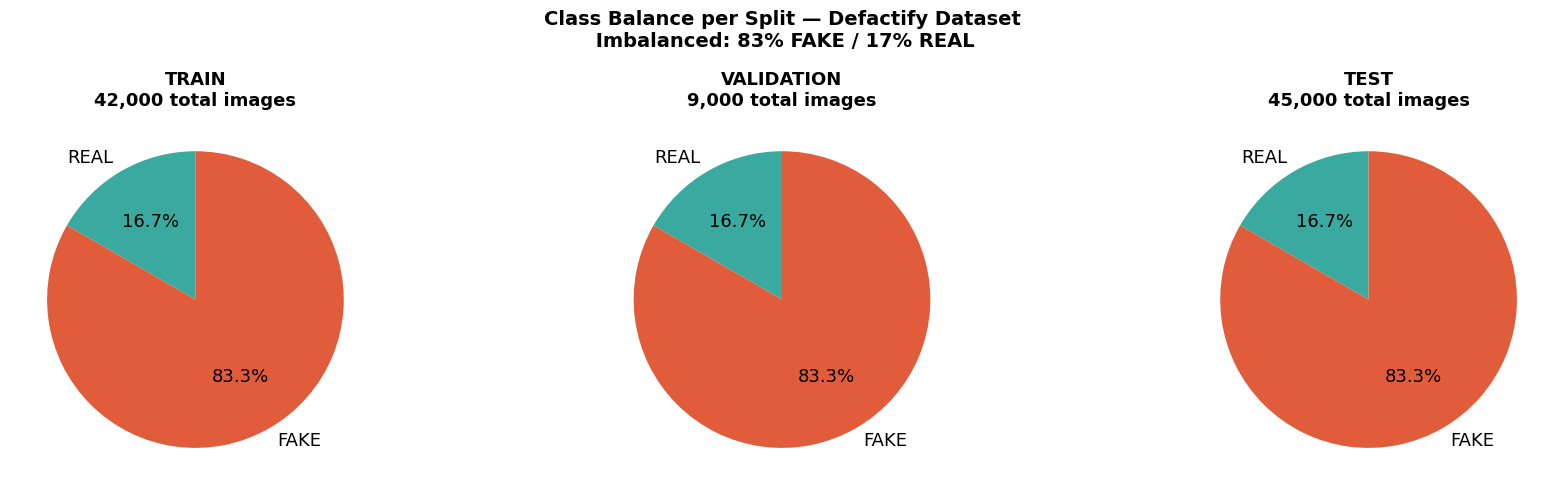

In [ ]:
#  Count per split and class 
records = []
for split in ['train', 'validation', 'test']:
    labels = hf_data[split]['Label_A']
    real_n = labels.count(0)
    fake_n = labels.count(1)
    records.append({'Split': split, 'REAL (Label_A=0)': real_n, 'FAKE (Label_A=1)': fake_n, 'Total': len(labels)})

df_balance = pd.DataFrame(records)
df_balance['REAL %'] = (df_balance['REAL (Label_A=0)'] / df_balance['Total'] * 100).round(1)
df_balance['FAKE %'] = (df_balance['FAKE (Label_A=1)'] / df_balance['Total'] * 100).round(1)
print(df_balance.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, row in df_balance.iterrows():
    axes[i].pie(
        [row['REAL (Label_A=0)'], row['FAKE (Label_A=1)']],
        labels=['REAL', 'FAKE'],
        colors=['#3AA99F', '#E05C3A'],
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 13}
    )
    axes[i].set_title(f"{row['Split'].upper()}\n{row['Total']:,} total images",
                      fontweight='bold', fontsize=13)

plt.suptitle('Class Balance per Split — Defactify Dataset\n Imbalanced: 83% FAKE / 17% REAL',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('defactify_balance.png', dpi=150, bbox_inches='tight')
plt.show()

print()

## Step 4 : Generator Distribution (Label_B)

Label_B tells us which AI generator created each fake image. Let's see how many fakes come from each generator — this helps us understand the diversity of the dataset.

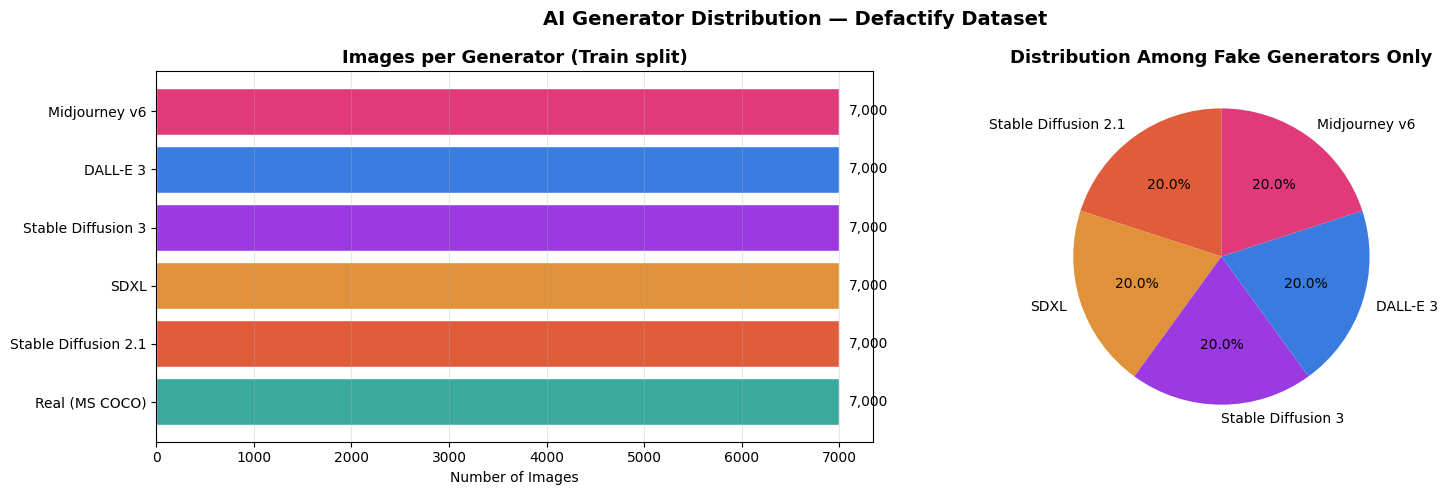

In [6]:
generator_map = {
    0: 'Real (MS COCO)',
    1: 'Stable Diffusion 2.1',
    2: 'SDXL',
    3: 'Stable Diffusion 3',
    4: 'DALL-E 3',
    5: 'Midjourney v6'
}

train_label_b = hf_data['train']['Label_B']
counts = Counter(train_label_b) if False else {k: train_label_b.count(k) for k in range(6)}

labels_b = [generator_map[k] for k in sorted(counts.keys())]
values_b  = [counts[k] for k in sorted(counts.keys())]
colors_b  = ['#3AA99F', '#E05C3A', '#E0913A', '#9B3AE0', '#3A7BE0', '#E03A7B']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
bars = axes[0].barh(labels_b, values_b, color=colors_b, edgecolor='white')
axes[0].set_title('Images per Generator (Train split)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Number of Images')
axes[0].grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, values_b):
    axes[0].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=10)

# Pie chart (fake generators only)
fake_labels = labels_b[1:]
fake_values = values_b[1:]
axes[1].pie(fake_values, labels=fake_labels, colors=colors_b[1:],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Distribution Among Fake Generators Only', fontweight='bold', fontsize=13)

plt.suptitle('AI Generator Distribution — Defactify Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('generator_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5 : Visual Samples: REAL vs Each AI Generator

Let's look at actual images : one real MS COCO image and one fake from each of the 5 AI generators. This shows how different each generator looks

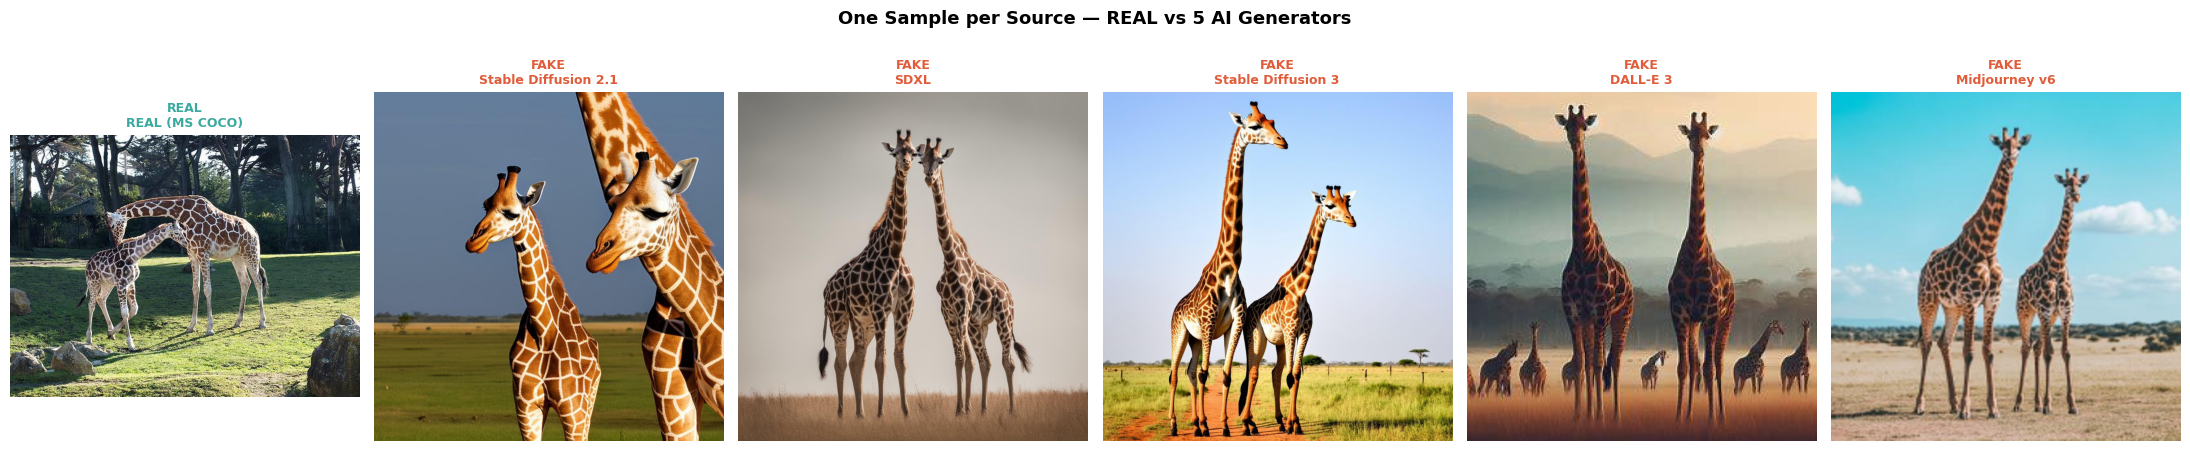

In [7]:
# Get one sample per generator
samples = {}
for target_b in range(6):
    for i in range(len(hf_data['train'])):
        if hf_data['train'][i]['Label_B'] == target_b:
            samples[target_b] = hf_data['train'][i]
            break

generator_names = [
    'REAL (MS COCO)',
    'Stable Diffusion 2.1',
    'SDXL',
    'Stable Diffusion 3',
    'DALL-E 3',
    'Midjourney v6'
]

fig, axes = plt.subplots(1, 6, figsize=(22, 5))

for col, (label_b, name) in enumerate(zip(range(6), generator_names)):
    item  = samples[label_b]
    img   = item['Image'].convert('RGB')
    caption = item['Caption'][:40] if item['Caption'] else ''
    is_real = item['Label_A'] == 0
    color = '#3AA99F' if is_real else '#E05C3A'
    tag   = 'REAL' if is_real else 'FAKE'
    axes[col].imshow(img)
    axes[col].set_title(f'{tag}\n{name}', color=color, fontweight='bold', fontsize=9)
    axes[col].set_xlabel(f'"{caption}..."', fontsize=7, wrap=True)
    axes[col].axis('off')

plt.suptitle('One Sample per Source — REAL vs 5 AI Generators', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('generator_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6 : Image Size & Resolution Analysis

Unlike Dataset 1 (fixed 256×256), Defactify images come from MS COCO and various generators — they may have different resolutions. Let's check

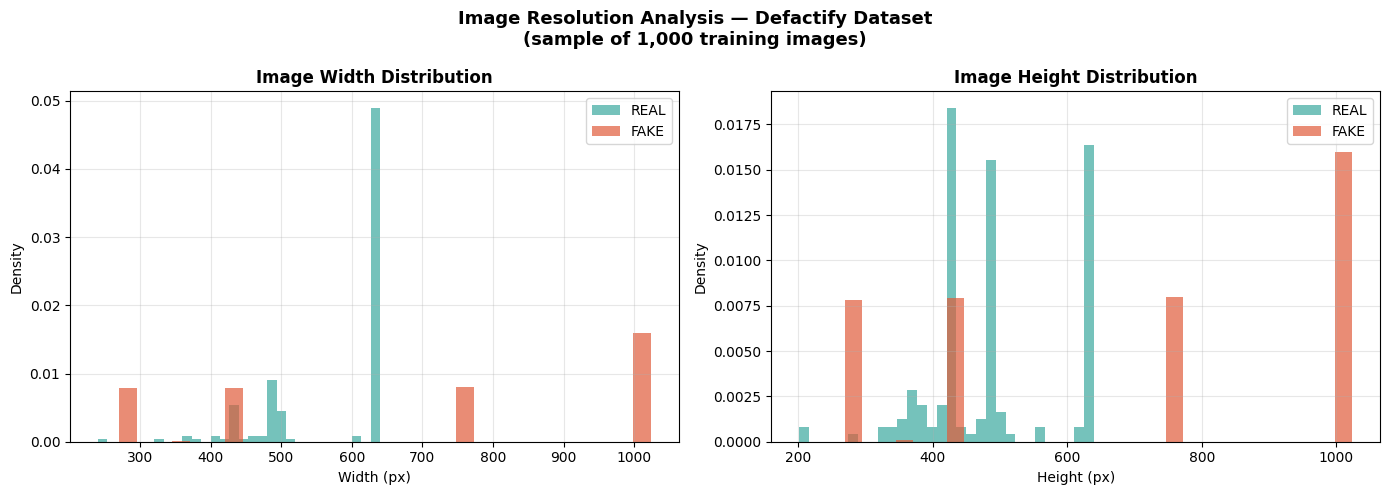

Width  stats: {'count': 1000.0, 'mean': 684.106, 'std': 285.82882444022414, 'min': 240.0, '25%': 436.0, '50%': 768.0, '75%': 1024.0, 'max': 1024.0}
Height stats: {'count': 1000.0, 'mean': 668.775, 'std': 293.9776509094415, 'min': 201.0, '25%': 436.0, '50%': 768.0, '75%': 1024.0, 'max': 1024.0}

All images will be resized to 224×224 during preprocessing


In [8]:
widths, heights, label_as = [], [], []

for i in range(0, min(1000, len(hf_data['train']))):
    item = hf_data['train'][i]
    img  = item['Image']
    widths.append(img.width)
    heights.append(img.height)
    label_as.append(item['Label_A'])

df_sizes = pd.DataFrame({'width': widths, 'height': heights, 'label': label_as})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Width distribution
axes[0].hist(df_sizes[df_sizes['label']==0]['width'], bins=30, alpha=0.7, color='#3AA99F', label='REAL', density=True)
axes[0].hist(df_sizes[df_sizes['label']==1]['width'], bins=30, alpha=0.7, color='#E05C3A', label='FAKE', density=True)
axes[0].set_title('Image Width Distribution', fontweight='bold')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Height distribution
axes[1].hist(df_sizes[df_sizes['label']==0]['height'], bins=30, alpha=0.7, color='#3AA99F', label='REAL', density=True)
axes[1].hist(df_sizes[df_sizes['label']==1]['height'], bins=30, alpha=0.7, color='#E05C3A', label='FAKE', density=True)
axes[1].set_title('Image Height Distribution', fontweight='bold')
axes[1].set_xlabel('Height (px)')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Image Resolution Analysis — Defactify Dataset\n(sample of 1,000 training images)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('resolution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Width  stats:', df_sizes['width'].describe().to_dict())
print('Height stats:', df_sizes['height'].describe().to_dict())
print()
print('All images will be resized to 224×224 during preprocessing')

## Step 7 : Pixel Statistics: REAL vs FAKE

We analyze R, G, B channel distributions for real MS COCO images vs AI-generated ones. Modern generators (DALL-E 3, Midjourney) often produce images with slightly different color saturation than real photographs.

Sampling pixel statistics...


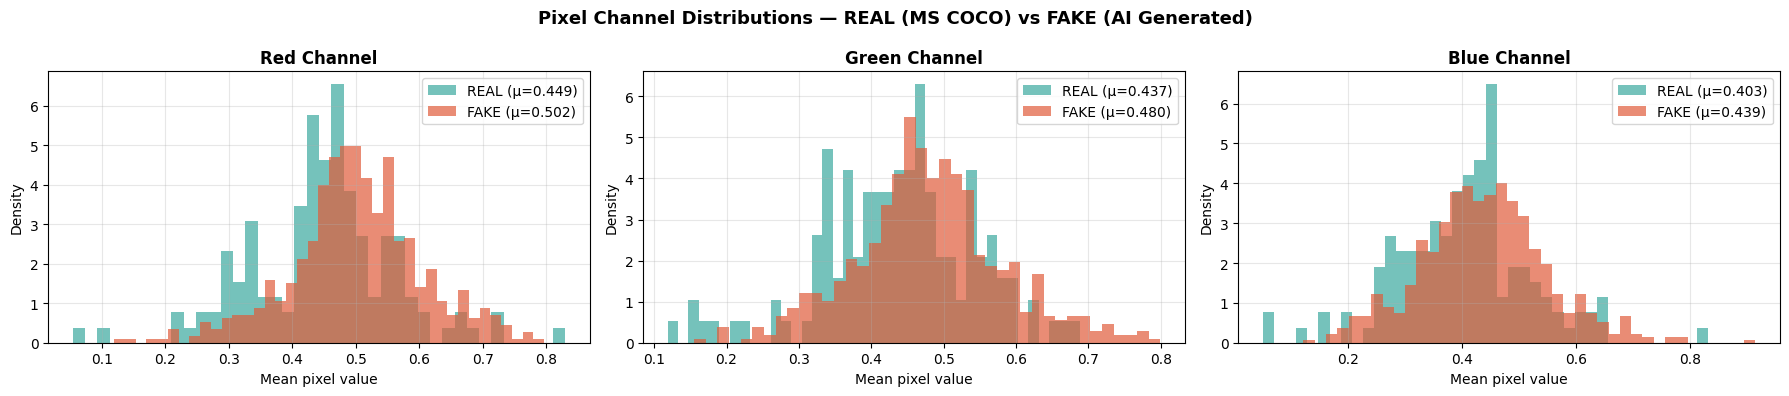

In [9]:
print('Sampling pixel statistics...')

R_real, G_real, B_real = [], [], []
R_fake, G_fake, B_fake = [], [], []

for i in range(min(800, len(hf_data['train']))):
    item = hf_data['train'][i]
    arr  = np.array(item['Image'].convert('RGB').resize((64, 64))) / 255.0
    if item['Label_A'] == 0:  # REAL
        R_real.append(arr[:,:,0].mean())
        G_real.append(arr[:,:,1].mean())
        B_real.append(arr[:,:,2].mean())
    else:  # FAKE
        R_fake.append(arr[:,:,0].mean())
        G_fake.append(arr[:,:,1].mean())
        B_fake.append(arr[:,:,2].mean())

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, real, fake, channel in zip(
    axes,
    [R_real, G_real, B_real],
    [R_fake, G_fake, B_fake],
    ['Red Channel', 'Green Channel', 'Blue Channel']
):
    ax.hist(real, bins=40, alpha=0.7, color='#3AA99F',
            label=f'REAL (μ={np.mean(real):.3f})', density=True)
    ax.hist(fake, bins=40, alpha=0.7, color='#E05C3A',
            label=f'FAKE (μ={np.mean(fake):.3f})', density=True)
    ax.set_title(channel, fontweight='bold')
    ax.set_xlabel('Mean pixel value')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Pixel Channel Distributions — REAL (MS COCO) vs FAKE (AI Generated)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('defactify_pixel_stats.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8 : Caption Analysis

The Defactify dataset includes a text caption for each image. Let's explore the captions — they can reveal what kinds of scenes are most common in the dataset

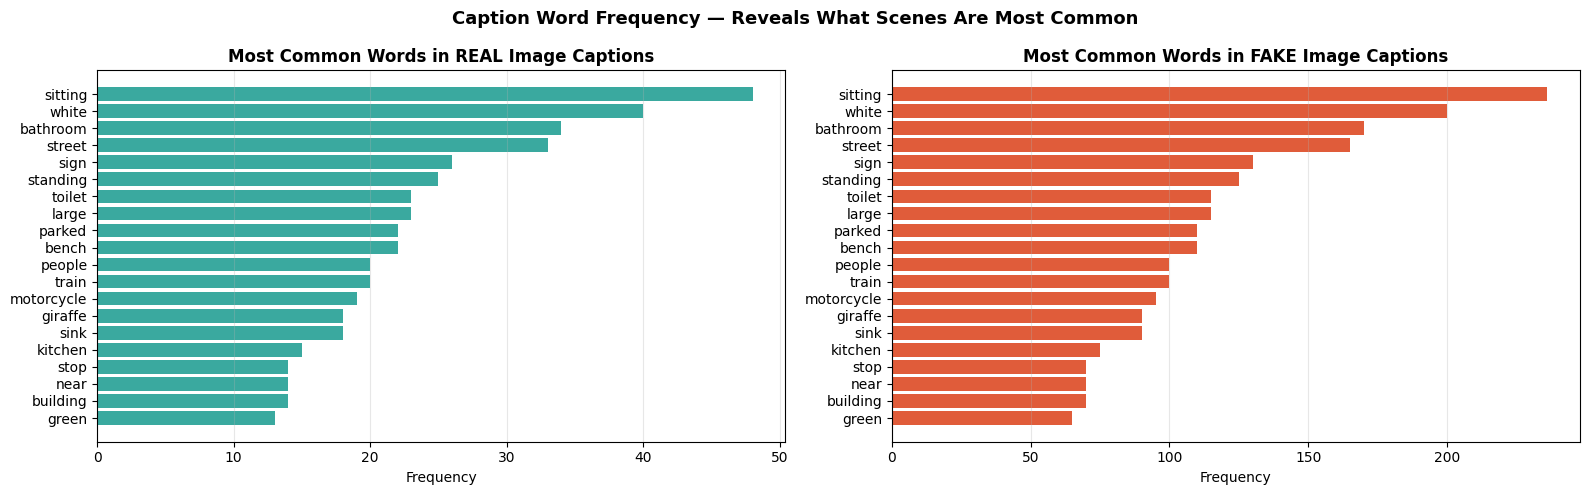

Top 5 real caption words: [('sitting', 48), ('white', 40), ('bathroom', 34), ('street', 33), ('sign', 26)]
Top 5 fake caption words: [('sitting', 236), ('white', 200), ('bathroom', 170), ('street', 165), ('sign', 130)]


In [10]:
from collections import Counter
import re

captions_real = []
captions_fake = []

for i in range(min(2000, len(hf_data['train']))):
    item = hf_data['train'][i]
    cap  = item['Caption'] or ''
    if item['Label_A'] == 0:
        captions_real.append(cap)
    else:
        captions_fake.append(cap)

# Most common words in captions
def top_words(captions, n=20):
    words = []
    for cap in captions:
        words.extend(re.findall(r'\b[a-z]{4,}\b', cap.lower()))
    stopwords = {'with', 'that', 'this', 'from', 'have', 'some', 'there',
                 'their', 'next', 'each', 'over', 'also', 'into', 'been'}
    return Counter(w for w in words if w not in stopwords).most_common(n)

top_real = top_words(captions_real)
top_fake = top_words(captions_fake)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

words_r, counts_r = zip(*top_real)
axes[0].barh(words_r[::-1], counts_r[::-1], color='#3AA99F')
axes[0].set_title('Most Common Words in REAL Image Captions', fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].grid(True, alpha=0.3, axis='x')

words_f, counts_f = zip(*top_fake)
axes[1].barh(words_f[::-1], counts_f[::-1], color='#E05C3A')
axes[1].set_title('Most Common Words in FAKE Image Captions', fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Caption Word Frequency — Reveals What Scenes Are Most Common',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('caption_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 real caption words:', top_real[:5])
print('Top 5 fake caption words:', top_fake[:5])